### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import csv
import json
import time

In [2]:
OUTPUT_DIR = Path("../outputs/PA3")

### Loading Dataset and Basic information

In [3]:
# Instruction 2: load provided files

X = np.loadtxt("../inputs/AI201_2S2025-26_PA3_Neural_Network/data.csv", delimiter=",", dtype=np.float64)
y = np.loadtxt("../inputs/AI201_2S2025-26_PA3_Neural_Network/data_labels.csv", delimiter=",", dtype=int).reshape(-1)

print("X shape:", X.shape)         # expected (3486, 354)
print("y shape:", y.shape)         # expected (3486,)
print("Class distribution:", Counter(y))

X shape: (3486, 354)
y shape: (3486,)
Class distribution: Counter({np.int64(1): 1625, np.int64(4): 483, np.int64(8): 466, np.int64(6): 310, np.int64(5): 287, np.int64(2): 233, np.int64(7): 52, np.int64(3): 30})


### Applying Smote

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("Original class distribution:", Counter(y))
print("Balanced class distribution:", Counter(y_balanced))
print("Balanced X shape:", X_balanced.shape)
print("Balanced y shape:", y_balanced.shape)

Original class distribution: Counter({np.int64(1): 1625, np.int64(4): 483, np.int64(8): 466, np.int64(6): 310, np.int64(5): 287, np.int64(2): 233, np.int64(7): 52, np.int64(3): 30})
Balanced class distribution: Counter({np.int64(8): 1625, np.int64(5): 1625, np.int64(1): 1625, np.int64(6): 1625, np.int64(4): 1625, np.int64(2): 1625, np.int64(3): 1625, np.int64(7): 1625})
Balanced X shape: (13000, 354)
Balanced y shape: (13000,)


In [5]:
def stratified_split_exact_800(X, y, val_size=800, seed=42):
    rng = np.random.default_rng(seed)

    classes, counts = np.unique(y, return_counts=True)
    total = len(y)

    # initial proportional allocation
    raw_counts = counts / total * val_size
    val_counts = np.floor(raw_counts).astype(int)

    # distribute remainder by largest fractional parts
    remainder = val_size - val_counts.sum()
    fractional_parts = raw_counts - val_counts
    order = np.argsort(-fractional_parts)

    for i in range(remainder):
        val_counts[order[i]] += 1

    train_indices = []
    val_indices = []

    for cls, n_val in zip(classes, val_counts):
        cls_idx = np.where(y == cls)[0]
        cls_idx = rng.permutation(cls_idx)

        val_indices.extend(cls_idx[:n_val])
        train_indices.extend(cls_idx[n_val:])

    val_indices = np.array(val_indices)
    train_indices = np.array(train_indices)

    # final shuffle
    val_indices = rng.permutation(val_indices)
    train_indices = rng.permutation(train_indices)

    return X[train_indices], y[train_indices], X[val_indices], y[val_indices]

def dataset_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    
    indices = np.random.permutation(len(X))
    
    split = int(len(X) * (1 - test_size))
    
    train_idx = indices[:split]
    test_idx = indices[split:]
    
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_val, y_val = stratified_split_exact_800(X_balanced, y_balanced, val_size=800, seed=42)

X_train, y_train, X_test, y_test = dataset_split(X_train, y_train, 0.3, 42)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("Validation distribution:", Counter(y_val))
print("Training distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

def save_csv(filename, array):
    np.savetxt(filename, array, delimiter=",", fmt="%.10f")

save_csv(f"{OUTPUT_DIR}/training_labels.csv", y_train)
save_csv(f"{OUTPUT_DIR}/training_set.csv.csv", X_train)
save_csv(f"{OUTPUT_DIR}/validation_labels.csv", y_val)
save_csv(f"{OUTPUT_DIR}/validation_set.csv", X_val)
save_csv(f"{OUTPUT_DIR}/test_labels.csv", y_test)
save_csv(f"{OUTPUT_DIR}/test_set.csv", X_test)

Training set: (8540, 354) (8540,)
Validation set: (800, 354) (800,)
Test set: (3660, 354) (3660,)
Validation distribution: Counter({np.int64(3): 100, np.int64(8): 100, np.int64(2): 100, np.int64(7): 100, np.int64(4): 100, np.int64(6): 100, np.int64(1): 100, np.int64(5): 100})
Training distribution: Counter({np.int64(5): 1100, np.int64(8): 1082, np.int64(6): 1080, np.int64(3): 1068, np.int64(4): 1060, np.int64(2): 1058, np.int64(7): 1053, np.int64(1): 1039})
Test distribution: Counter({np.int64(1): 486, np.int64(7): 472, np.int64(2): 467, np.int64(4): 465, np.int64(3): 457, np.int64(6): 445, np.int64(8): 443, np.int64(5): 425})


### Helpers

In [6]:
def sigmoid(x, a=2.0, derivative=False):
    if derivative:
        y = x
        return a * y * (1 - y)
    return 1 / (1 + np.exp(-a * x))


def hyperbolic_tangent(x, a=1.716, b=2/3, derivative=False):
    if derivative:
        y = x
        return (b / a) * (a - y) * (a + y)
    return a * np.tanh(b * x)


def leaky_relu(x, pos_slope=1.0, neg_slope=0.01, derivative=False):
    if derivative:
        grad = np.ones_like(x) * pos_slope
        grad[x < 0] = neg_slope
        return grad
    return np.where(x >= 0, pos_slope * x, neg_slope * x)

ACTIVATIONS = {
    "logistic": sigmoid,
    "tanh": hyperbolic_tangent,
    "leaky_relu": leaky_relu
}

In [7]:
def one_hot_encode(y, num_classes=8):
    """
    Expects y labels in {1,...,8}
    Returns shape (N, num_classes)
    """
    y = np.asarray(y).astype(int).reshape(-1)
    oh = np.zeros((len(y), num_classes), dtype=np.float64)
    oh[np.arange(len(y)), y - 1] = 1.0
    return oh

def decode_one_hot(y_onehot):
    """
    Converts network outputs or one-hot rows to labels {1,...,8}
    """
    return np.argmax(y_onehot, axis=1) + 1

def save_int_csv(filename, array):
    np.savetxt(filename, array, delimiter=",", fmt="%d")

def save_list_csv(filename, header, rows):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        if header is not None:
            writer.writerow(header)
        writer.writerows(rows)

def shuffle_in_unison(X, y, rng):
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

### Class-wrap MLP Model

In [8]:
import numpy as np

class MLP2Hidden:
    def __init__(
        self,
        input_nodes,
        hidden1_nodes,
        hidden2_nodes,
        output_nodes,
        act_h1="tanh",
        act_h2="tanh",
        act_out="logistic",
        act_h1_params=None,
        act_h2_params=None,
        act_out_params=None,
        model_name: str = "Baseline Model",
        seed=42
    ):
        self.rng = np.random.default_rng(seed)

        self.act_h1_name = act_h1
        self.act_h2_name = act_h2
        self.act_out_name = act_out

        self.act_h1 = ACTIVATIONS[act_h1]
        self.act_h2 = ACTIVATIONS[act_h2]
        self.act_out = ACTIVATIONS[act_out]

        self.act_h1_params = act_h1_params or {}
        self.act_h2_params = act_h2_params or {}
        self.act_out_params = act_out_params or {}

        # Xavier-like init
        self.W1 = self.rng.normal(0, np.sqrt(2 / (input_nodes + hidden1_nodes)), size=(input_nodes, hidden1_nodes))
        self.b1 = np.zeros((1, hidden1_nodes))

        self.W2 = self.rng.normal(0, np.sqrt(2 / (hidden1_nodes + hidden2_nodes)), size=(hidden1_nodes, hidden2_nodes))
        self.b2 = np.zeros((1, hidden2_nodes))

        self.W3 = self.rng.normal(0, np.sqrt(2 / (hidden2_nodes + output_nodes)), size=(hidden2_nodes, output_nodes))
        self.b3 = np.zeros((1, output_nodes))


        # Momentum buffers
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)
        self.vW3 = np.zeros_like(self.W3)
        self.vb3 = np.zeros_like(self.b3)

        # Config
        self.model_name = model_name

    def forward(self, X):
        v1 = X @ self.W1 + self.b1
        y1 = self.act_h1(v1, **self.act_h1_params)

        v2 = y1 @ self.W2 + self.b2
        y2 = self.act_h2(v2, **self.act_h2_params)

        v_out = y2 @ self.W3 + self.b3
        y_out = self.act_out(v_out, **self.act_out_params)

        cache = {
            "X": X,
            "v1": v1, "y1": y1,
            "v2": v2, "y2": y2,
            "v_out": v_out, "y_out": y_out
        }
        return y_out, cache

    def batch_sse(self, y_true, y_pred):
        return 0.5 * np.sum((y_true - y_pred) ** 2)
    
    def backward(self, y_true, cache, lr=0.01, alpha=0.9):
        X = cache["X"]
        v1, y1 = cache["v1"], cache["y1"]
        v2, y2 = cache["v2"], cache["y2"]
        v_out, y_out = cache["v_out"], cache["y_out"]

        m = X.shape[0]

        # Output delta
        d_out = (y_true - y_out) * self.act_out(y_out, derivative=True, **self.act_out_params)

        # Hidden 2 delta
        d_h2 = (d_out @ self.W3.T) * self.act_h2(y2, derivative=True, **self.act_h2_params)

        # Hidden 1 delta
        d_h1 = (d_h2 @ self.W2.T)* self.act_h1(y1, derivative=True, **self.act_h1_params)

        # Gradients
        gW3 = (y2.T @ d_out) / m
        gb3 = np.sum(d_out, axis=0, keepdims=True) / m

        gW2 = (y1.T @ d_h2) / m
        gb2 = np.sum(d_h2, axis=0, keepdims=True) / m

        gW1 = (X.T @ d_h1) / m
        gb1 = np.sum(d_h1, axis=0, keepdims=True) / m

        # Generalized delta rule with momentum
        self.vW3 = alpha * self.vW3 + lr * gW3
        self.vb3 = alpha * self.vb3 + lr * gb3
        self.vW2 = alpha * self.vW2 + lr * gW2
        self.vb2 = alpha * self.vb2 + lr * gb2
        self.vW1 = alpha * self.vW1 + lr * gW1
        self.vb1 = alpha * self.vb1 + lr * gb1

        self.W3 += self.vW3
        self.b3 += self.vb3
        self.W2 += self.vW2
        self.b2 += self.vb2
        self.W1 += self.vW1
        self.b1 += self.vb1

    def predict_proba(self, X):
        yhat, _ = self.forward(X)
        return yhat

    def predict(self, X):
        return decode_one_hot(self.predict_proba(X))

    def save_weights(self, prefix="trained_weights"):
        np.savez(
            f"{prefix}.npz",
            W1=self.W1, b1=self.b1,
            W2=self.W2, b2=self.b2,
            W3=self.W3, b3=self.b3,
            act_h1_name=self.act_h1_name,
            act_h2_name=self.act_h2_name,
            act_out_name=self.act_out_name,
            act_h1_params=json.dumps(self.act_h1_params),
            act_h2_params=json.dumps(self.act_h2_params),
            act_out_params=json.dumps(self.act_out_params)
        )

    def load_weights(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        self.W1 = data["W1"]
        self.b1 = data["b1"]
        self.W2 = data["W2"]
        self.b2 = data["b2"]
        self.W3 = data["W3"]
        self.b3 = data["b3"]

        self.act_h1_name = str(data["act_h1_name"])
        self.act_h2_name = str(data["act_h2_name"])
        self.act_out_name = str(data["act_out_name"])

        self.act_h1 = ACTIVATIONS[self.act_h1_name]
        self.act_h2 = ACTIVATIONS[self.act_h2_name]
        self.act_out = ACTIVATIONS[self.act_out_name]

        self.act_h1_params = json.loads(str(data["act_h1_params"]))
        self.act_h2_params = json.loads(str(data["act_h2_params"]))
        self.act_out_params = json.loads(str(data["act_out_params"]))


In [9]:
def confusion_matrix_np(y_true, y_pred, num_classes=8):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t - 1, p - 1] += 1
    return cm

def classification_metrics_from_cm(cm):
    """
    Multi-class metrics from confusion matrix.
    Returns macro precision, recall, f1, accuracy, MCC.
    """
    num_classes = cm.shape[0]
    total = cm.sum()
    correct = np.trace(cm)

    precision_list = []
    recall_list = []
    f1_list = []

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    accuracy = correct / total if total > 0 else 0.0

    # Multi-class MCC (Gorodkin-style implementation using confusion matrix)
    t_sum = cm.sum(axis=1)
    p_sum = cm.sum(axis=0)
    c = correct
    s = total

    numerator = c * s - np.dot(t_sum, p_sum)
    denominator = np.sqrt((s**2 - np.dot(p_sum, p_sum)) * (s**2 - np.dot(t_sum, t_sum)))
    mcc = numerator / denominator if denominator > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision_macro": np.mean(precision_list),
        "recall_macro": np.mean(recall_list),
        "f1_macro": np.mean(f1_list),
        "mcc": mcc,
        "precision_per_class": precision_list,
        "recall_per_class": recall_list,
        "f1_per_class": f1_list
    }

def save_metrics(filename, metrics_dict):
    rows = []
    for k, v in metrics_dict.items():
        if isinstance(v, list):
            rows.append([k] + v)
        else:
            rows.append([k, v])

    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["metric", "value_1", "value_2", "value_3", "value_4",
                         "value_5", "value_6", "value_7", "value_8"])
        for row in rows:
            writer.writerow(row)

In [10]:
# Training
def train_model(
    model,
    X_train,
    y_train_oh,
    X_val,
    y_val_oh,
    y_val_labels,
    epochs=50,
    batch_size=8,
    lr=0.01,
    alpha=0.9,
    seed=42,
    prefix = "network a"
):
    rng = np.random.default_rng(seed)

    train_sse_history = []
    val_eval_history = []  # every 5 epochs: epoch, val_sse, miscls
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        X_train, y_train_oh = shuffle_in_unison(X_train, y_train_oh, rng)

        epoch_sse = 0.0

        for i in range(0, len(X_train), batch_size):
            xb = X_train[i:i+batch_size]
            yb = y_train_oh[i:i+batch_size]

            yhat, cache = model.forward(xb)
            batch_sse = model.batch_sse(yb, yhat)
            epoch_sse += batch_sse

            model.backward(yb, cache, lr=lr, alpha=alpha)

        train_sse_history.append([epoch, epoch_sse])

        if epoch % 5 == 0:
            val_pred_proba = model.predict_proba(X_val)
            val_sse = model.batch_sse(y_val_oh, val_pred_proba)
            val_pred = decode_one_hot(val_pred_proba)
            miscls = int(np.sum(val_pred != y_val_labels))
            val_eval_history.append([epoch, val_sse, miscls])

            print(f"{epoch}/{epochs} train_sse={epoch_sse:.4f} val_sse={val_sse:.4f} miscls={miscls}")
        else:
            print(f"{epoch}/{epochs} train_sse={epoch_sse:.4f}")

    elapsed = time.time() - start_time

    # Final validation evaluation
    y_val_pred = model.predict(X_val)
    cm = confusion_matrix_np(y_val_labels, y_val_pred, num_classes=8)
    metrics = classification_metrics_from_cm(cm)

    if prefix is not None:
        # Save SSE history
        save_list_csv(f"{prefix}_training_sse.csv", ["epoch", "training_sse"], train_sse_history)
        save_list_csv(f"{prefix}_validation_metrics.csv", ["epoch", "validation_sse", "misclassifications"], val_eval_history)

        save_int_csv(f"{prefix}_confusion_matrix.csv", cm)
        save_metrics(f"{prefix}_classification_metrics.csv", metrics)
        model.save_weights(prefix=f"{prefix}_trained_weights")

    return {
        "train_sse_history": np.array(train_sse_history, dtype=float),
        "val_eval_history": np.array(val_eval_history, dtype=float),
        "confusion_matrix": cm,
        "metrics": metrics,
        "training_time_sec": elapsed
    }

In [11]:
def plot_learning_curves(train_hist, val_hist, title="Learning Curves"):
    plt.figure(figsize=(10, 5))
    plt.plot(train_hist[:, 0], train_hist[:, 1], label="Training SSE")
    if len(val_hist) > 0:
        plt.plot(val_hist[:, 0], val_hist[:, 1], marker="o", label="Validation SSE")
    plt.xlabel("Epoch")
    plt.ylabel("SSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
# One-hot versions for training
y_train_oh = one_hot_encode(y_train, num_classes=8)
y_val_oh = one_hot_encode(y_val, num_classes=8)
y_test_oh = one_hot_encode(y_test, num_classes=8)

1/50 train_sse=2385.8328
2/50 train_sse=1341.6619
3/50 train_sse=1004.3361
4/50 train_sse=901.6392
5/50 train_sse=776.0593 val_sse=63.1923 miscls=65
6/50 train_sse=661.4823
7/50 train_sse=635.3318
8/50 train_sse=660.6123
9/50 train_sse=568.3135
10/50 train_sse=563.2147 val_sse=35.2201 miscls=29
11/50 train_sse=466.6925
12/50 train_sse=467.2552
13/50 train_sse=462.1836
14/50 train_sse=424.2391
15/50 train_sse=409.2962 val_sse=50.8480 miscls=54
16/50 train_sse=360.0433
17/50 train_sse=360.7476
18/50 train_sse=384.1226
19/50 train_sse=341.5113
20/50 train_sse=410.6635 val_sse=26.7226 miscls=25
21/50 train_sse=301.9683
22/50 train_sse=306.4284
23/50 train_sse=294.9905
24/50 train_sse=289.9430
25/50 train_sse=296.5878 val_sse=20.6175 miscls=22
26/50 train_sse=304.8085
27/50 train_sse=271.0716
28/50 train_sse=267.6136
29/50 train_sse=261.6369
30/50 train_sse=248.2512 val_sse=29.2675 miscls=26
31/50 train_sse=248.1581
32/50 train_sse=252.6101
33/50 train_sse=236.2245
34/50 train_sse=249.9357


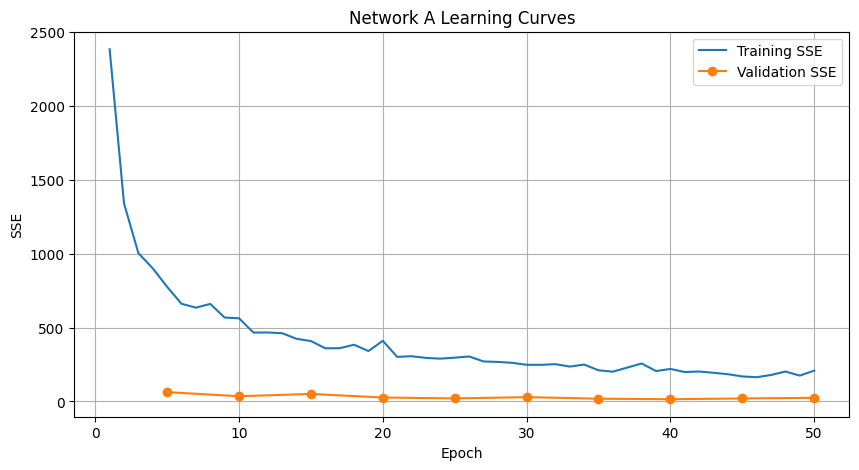

Confusion matrix:
 [[ 96   1   0   0   0   0   0   3]
 [  0  97   0   0   0   0   0   3]
 [  0   0 100   0   0   0   0   0]
 [  0   0   0  99   0   0   0   1]
 [  0   0   0   0 100   0   0   0]
 [  0   0   0   0   0  97   0   3]
 [  0   0   0   0   0   0  95   5]
 [  0   0   0   3   0   2   0  95]]


In [13]:
network_a = MLP2Hidden(
    input_nodes=354,
    hidden1_nodes=181,
    hidden2_nodes=181,
    output_nodes=8,
    act_h1="tanh",
    act_h2="tanh",
    act_out="logistic",
    act_h1_params={"a": 1.716, "b": 2/3},
    act_h2_params={"a": 1.716, "b": 2/3},
    act_out_params={"a": 2.0},
    model_name= "Network A",
    seed=42
)

prefix = OUTPUT_DIR / network_a.model_name

results_a = train_model(
    model=network_a,
    X_train=X_train,
    y_train_oh=y_train_oh,
    X_val=X_val,
    y_val_oh=y_val_oh,
    y_val_labels=y_val,
    epochs=50,
    batch_size=8,
    lr=0.01,
    alpha=0.9,
    seed=42,
    prefix=prefix
)

print("Training time (sec):", results_a["training_time_sec"])
print("Metrics:", results_a["metrics"])
plot_learning_curves(
    results_a["train_sse_history"],
    results_a["val_eval_history"],
    title="Network A Learning Curves"
)
print("Confusion matrix:\n", results_a["confusion_matrix"])

### Hyperparameter Tuning on Network A

In [14]:
hidden_options = [
    (64, 32),
    (128, 64),
    (128, 128),
    (181, 128)
]

lr_options = [0.001, 0.005, 0.01, 0.05]
alpha_options = [0.8, 0.9, 0.95]

tuning_results_a = []

for h1, h2 in hidden_options:
    for lr in lr_options:
        for alpha in alpha_options:
            print(f"\nTraining Network A with h1={h1}, h2={h2}, lr={lr}, alpha={alpha}")

            model = MLP2Hidden(
                input_nodes=354,
                hidden1_nodes=h1,
                hidden2_nodes=h2,
                output_nodes=8,
                act_h1="tanh",
                act_h2="tanh",
                act_out="logistic",
                act_h1_params={"a": 1.716, "b": 2/3},
                act_h2_params={"a": 1.716, "b": 2/3},
                act_out_params={"a": 2.0},
                seed=42
            )

            res = train_model(
                model=model,
                X_train=X_train,
                y_train_oh=y_train_oh,
                X_val=X_val,
                y_val_oh=y_val_oh,
                y_val_labels=y_val,
                epochs=30,   
                batch_size=8,
                lr=lr,
                alpha=alpha,
                seed=42,
                prefix=None
            )

            # use last validation SSE and misclassifications
            last_val = res["val_eval_history"][-1]
            tuning_results_a.append({
                "h1": h1,
                "h2": h2,
                "lr": lr,
                "alpha": alpha,
                "final_val_sse": float(last_val[1]),
                "final_miscls": int(last_val[2]),
                "train_time_sec": res["training_time_sec"]
            })

# sort best by validation SSE then misclassifications
tuning_results_a = sorted(tuning_results_a, key=lambda d: (d["final_val_sse"], d["final_miscls"]))

print("Top 10 Network A configs:")
for row in tuning_results_a[:10]:
    print(row)


Training Network A with h1=64, h2=32, lr=0.001, alpha=0.8
1/30 train_sse=3785.9026
2/30 train_sse=3498.2312
3/30 train_sse=3310.5301
4/30 train_sse=3130.8019
5/30 train_sse=2952.9832 val_sse=272.2728 miscls=353
6/30 train_sse=2783.2151
7/30 train_sse=2632.0128
8/30 train_sse=2501.5527
9/30 train_sse=2382.7333
10/30 train_sse=2274.5885 val_sse=209.6284 miscls=218
11/30 train_sse=2173.2008
12/30 train_sse=2080.1289
13/30 train_sse=1993.3595
14/30 train_sse=1914.4063
15/30 train_sse=1841.9154 val_sse=171.0326 miscls=177
16/30 train_sse=1778.0752
17/30 train_sse=1717.4133
18/30 train_sse=1661.1778
19/30 train_sse=1607.1342
20/30 train_sse=1556.7971 val_sse=144.1925 miscls=125
21/30 train_sse=1504.9896
22/30 train_sse=1456.6873
23/30 train_sse=1408.8300
24/30 train_sse=1363.9454
25/30 train_sse=1320.1955 val_sse=122.3292 miscls=111
26/30 train_sse=1276.4906
27/30 train_sse=1236.8320
28/30 train_sse=1197.0765
29/30 train_sse=1159.4552
30/30 train_sse=1125.0484 val_sse=103.8934 miscls=82

Tr

### Train on the best Hyperparameters

In [15]:
# Retrain the best Network A configuration longer, then save as trained_weights

best_a = tuning_results_a[0]
print("Best A config:", best_a)

best_network_a = MLP2Hidden(
    input_nodes=354,
    hidden1_nodes=best_a["h1"],
    hidden2_nodes=best_a["h2"],
    output_nodes=8,
    act_h1="tanh",
    act_h2="tanh",
    act_out="logistic",
    act_h1_params={"a": 1.716, "b": 2/3},
    act_h2_params={"a": 1.716, "b": 2/3},
    act_out_params={"a": 2.0},
    seed=42
)

best_results_a = train_model(
    model=best_network_a,
    X_train=X_train,
    y_train_oh=y_train_oh,
    X_val=X_val,
    y_val_oh=y_val_oh,
    y_val_labels=y_val,
    epochs=100,
    batch_size=8,
    lr=best_a["lr"],
    alpha=best_a["alpha"],
    seed=42,
    prefix=f"{OUTPUT_DIR}/network_a_final"
)

Best A config: {'h1': 128, 'h2': 64, 'lr': 0.05, 'alpha': 0.8, 'final_val_sse': 11.341426534076193, 'final_miscls': 11, 'train_time_sec': 5.2245564460754395}
1/100 train_sse=2193.6196
2/100 train_sse=1288.8759
3/100 train_sse=1016.6051
4/100 train_sse=874.3789
5/100 train_sse=702.7973 val_sse=53.6726 miscls=61
6/100 train_sse=601.1017
7/100 train_sse=525.2951
8/100 train_sse=490.9431
9/100 train_sse=466.8637
10/100 train_sse=408.4119 val_sse=41.4288 miscls=52
11/100 train_sse=428.1903
12/100 train_sse=358.1250
13/100 train_sse=351.8705
14/100 train_sse=315.1952
15/100 train_sse=284.7827 val_sse=29.8540 miscls=33
16/100 train_sse=295.9993
17/100 train_sse=276.8741
18/100 train_sse=270.2257
19/100 train_sse=255.3001
20/100 train_sse=244.2442 val_sse=17.4901 miscls=18
21/100 train_sse=235.8466
22/100 train_sse=244.5619
23/100 train_sse=208.5107
24/100 train_sse=198.1334
25/100 train_sse=217.2354 val_sse=23.7336 miscls=26
26/100 train_sse=204.5212
27/100 train_sse=200.5394
28/100 train_sse

### Repeat using Leaky ReLU in both hidden layers = Network B

In [ ]:
# Network B with same hidden sizes as best Network A

h1_best = best_a["h1"]
h2_best = best_a["h2"]

hidden_lr_options = [0.001, 0.005, 0.01, 0.05]
hidden_alpha_options = [0.8, 0.9, 0.95]

tuning_results_b = []

for lr in hidden_lr_options:
    for alpha in hidden_alpha_options:
        print(f"\nTraining Network B with h1={h1_best}, h2={h2_best}, lr={lr}, alpha={alpha}")

        model = MLP2Hidden(
            input_nodes=354,
            hidden1_nodes=h1_best,
            hidden2_nodes=h2_best,
            output_nodes=8,
            act_h1="leaky_relu",
            act_h2="leaky_relu",
            act_out="logistic",
            act_h1_params={"pos_slope": 1.0, "neg_slope": 0.01},
            act_h2_params={"pos_slope": 1.0, "neg_slope": 0.01},
            act_out_params={"a": 2.0},
            seed=42
        )

        res = train_model(
            model=model,
            X_train=X_train,
            y_train_oh=y_train_oh,
            X_val=X_val,
            y_val_oh=y_val_oh,
            y_val_labels=y_val,
            epochs=30,
            batch_size=8,
            lr=lr,
            alpha=alpha,
            seed=42,
            prefix=None
        )

        last_val = res["val_eval_history"][-1]
        tuning_results_b.append({
            "lr": lr,
            "alpha": alpha,
            "final_val_sse": float(last_val[1]),
            "final_miscls": int(last_val[2]),
            "train_time_sec": res["training_time_sec"]
        })

tuning_results_b = sorted(tuning_results_b, key=lambda d: (d["final_val_sse"], d["final_miscls"]))

print("Top Network B configs:")
for row in tuning_results_b[:10]:
    print(row)


Training Network B with h1=128, h2=64, lr=0.001, alpha=0.8
1/30 train_sse=4108.8770
2/30 train_sse=3677.3490
3/30 train_sse=3633.1484
4/30 train_sse=3578.3058
5/30 train_sse=3500.7237 val_sse=324.8428 miscls=513
6/30 train_sse=3393.3299
7/30 train_sse=3263.4648
8/30 train_sse=3129.4535
9/30 train_sse=3005.5789
10/30 train_sse=2900.1183 val_sse=270.2331 miscls=412
11/30 train_sse=2808.4639
12/30 train_sse=2728.4166
13/30 train_sse=2652.2842
14/30 train_sse=2578.1099
15/30 train_sse=2505.1987 val_sse=234.1068 miscls=393
16/30 train_sse=2436.2066
17/30 train_sse=2367.7971
18/30 train_sse=2305.5858
19/30 train_sse=2250.0283
20/30 train_sse=2197.8475 val_sse=205.5412 miscls=259
21/30 train_sse=2148.1855
22/30 train_sse=2102.2454
23/30 train_sse=2056.2320
24/30 train_sse=2011.3068
25/30 train_sse=1966.6745 val_sse=183.7686 miscls=179
26/30 train_sse=1918.5727
27/30 train_sse=1871.9972
28/30 train_sse=1821.4315
29/30 train_sse=1771.8814
30/30 train_sse=1723.5067 val_sse=160.6781 miscls=158



Best B config: {'lr': 0.05, 'alpha': 0.8, 'final_val_sse': 12.380754235229592, 'final_miscls': 16, 'train_time_sec': 5.454519033432007}


1/100 train_sse=2522.9715
2/100 train_sse=1205.5242
3/100 train_sse=849.0795
4/100 train_sse=724.8440
5/100 train_sse=584.2097 val_sse=43.3919 miscls=47
6/100 train_sse=473.8669
7/100 train_sse=459.1851
8/100 train_sse=419.1991
9/100 train_sse=392.9541
10/100 train_sse=347.7036 val_sse=31.9651 miscls=39
11/100 train_sse=335.2186
12/100 train_sse=294.2425
13/100 train_sse=283.0518
14/100 train_sse=283.3676
15/100 train_sse=248.5654 val_sse=41.7965 miscls=49
16/100 train_sse=239.4670
17/100 train_sse=232.9061
18/100 train_sse=212.5816
19/100 train_sse=215.0271
20/100 train_sse=185.3181 val_sse=10.6839 miscls=12
21/100 train_sse=221.5113
22/100 train_sse=173.1191
23/100 train_sse=190.4561
24/100 train_sse=178.7389
25/100 train_sse=189.6660 val_sse=27.4416 miscls=38
26/100 train_sse=169.4136
27/100 train_sse=179.8721
28/100 train_sse=162.4915
29/100 train_sse=143.8985
30/100 train_sse=136.5017 val_sse=12.3808 miscls=16
31/100 train_sse=144.1076
32/100 train_sse=132.5290
33/100 train_sse=13

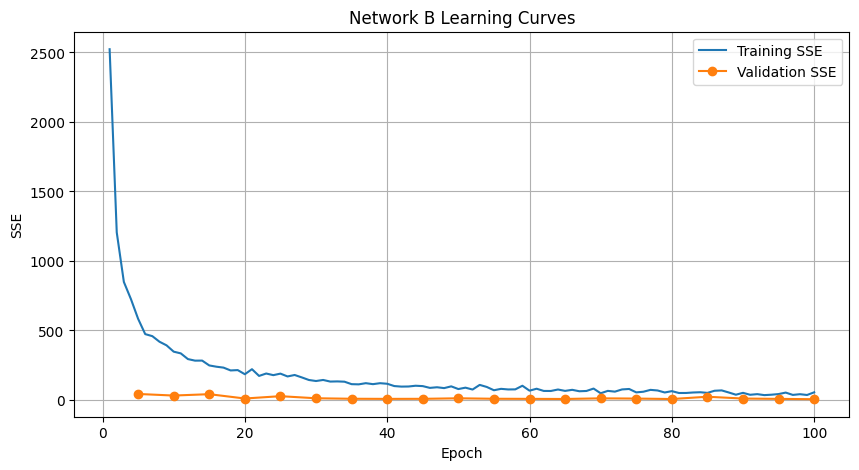

Network B confusion matrix:
 [[ 97   1   0   0   0   0   0   2]
 [  0 100   0   0   0   0   0   0]
 [  0   0 100   0   0   0   0   0]
 [  0   0   0  99   0   0   0   1]
 [  0   0   0   0 100   0   0   0]
 [  0   0   0   0   0 100   0   0]
 [  0   0   0   0   0   0 100   0]
 [  1   0   0   1   0   1   0  97]]
Network B metrics:
 {'accuracy': np.float64(0.99125), 'precision_macro': np.float64(0.9912492422711658), 'recall_macro': np.float64(0.99125), 'f1_macro': np.float64(0.9912309663802201), 'mcc': np.float64(0.990005303614047), 'precision_per_class': [np.float64(0.9897959183673469), np.float64(0.9900990099009901), np.float64(1.0), np.float64(0.99), np.float64(1.0), np.float64(0.9900990099009901), np.float64(1.0), np.float64(0.97)], 'recall_per_class': [np.float64(0.97), np.float64(1.0), np.float64(1.0), np.float64(0.99), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.97)], 'f1_per_class': [np.float64(0.9797979797979798), np.float64(0.9950248756218906), np.float64(1.0),

In [17]:
# Retrain best Network B longer

best_b = tuning_results_b[0]
print("Best B config:", best_b)

best_network_b = MLP2Hidden(
    input_nodes=354,
    hidden1_nodes=h1_best,
    hidden2_nodes=h2_best,
    output_nodes=8,
    act_h1="leaky_relu",
    act_h2="leaky_relu",
    act_out="logistic",
    act_h1_params={"pos_slope": 1.0, "neg_slope": 0.01},
    act_h2_params={"pos_slope": 1.0, "neg_slope": 0.01},
    act_out_params={"a": 2.0},
    seed=42
)

best_results_b = train_model(
    model=best_network_b,
    X_train=X_train,
    y_train_oh=y_train_oh,
    X_val=X_val,
    y_val_oh=y_val_oh,
    y_val_labels=y_val,
    epochs=100,
    batch_size=8,
    lr=best_b["lr"],
    alpha=best_b["alpha"],
    seed=42,
    prefix=f"{OUTPUT_DIR}/network_b_final"
)

plot_learning_curves(
    best_results_b["train_sse_history"],
    best_results_b["val_eval_history"],
    title="Network B Learning Curves"
)
print("Network B confusion matrix:\n", best_results_b["confusion_matrix"])
print("Network B metrics:\n", best_results_b["metrics"])

### Final Comparison on Test Set

In [22]:
# Load saved Network A weights and evaluate on Test Set

loaded_a = MLP2Hidden(
    input_nodes=354,
    hidden1_nodes=best_a["h1"],
    hidden2_nodes=best_a["h2"],
    output_nodes=8
)
loaded_a.load_weights(f"{OUTPUT_DIR}/network_a_final_trained_weights.npz")

y_val_pred_loaded_a = loaded_a.predict(X_test)
cm_loaded_a = confusion_matrix_np(y_test, y_val_pred_loaded_a, num_classes=8)
metrics_loaded_a = classification_metrics_from_cm(cm_loaded_a)

print("Loaded Network A metrics:", metrics_loaded_a)
print("Loaded Network A confusion matrix:\n", cm_loaded_a)

Loaded Network A metrics: {'accuracy': np.float64(0.989344262295082), 'precision_macro': np.float64(0.9893800584291724), 'recall_macro': np.float64(0.9893513417149222), 'f1_macro': np.float64(0.989276018110484), 'mcc': np.float64(0.9878451661198328), 'precision_per_class': [np.float64(0.9978858350951374), np.float64(0.9852320675105485), np.float64(0.9978165938864629), np.float64(0.9789473684210527), np.float64(0.9976525821596244), np.float64(0.9713024282560706), np.float64(0.9978858350951374), np.float64(0.9883177570093458)], 'recall_per_class': [np.float64(0.9711934156378601), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9887640449438202), np.float64(1.0), np.float64(0.9548532731376975)], 'f1_per_class': [np.float64(0.9843587069864442), np.float64(0.9925611052072263), np.float64(0.9989071038251366), np.float64(0.9893617021276596), np.float64(0.9988249118683901), np.float64(0.9799554565701559), np.float64(0.9989417989417989), np.float64(0.97129735935

In [23]:
# Load saved Network B weights and evaluate on Test Set

loaded_b = MLP2Hidden(
    input_nodes=354,
    hidden1_nodes=h1_best,
    hidden2_nodes=h2_best,
    output_nodes=8
)
loaded_b.load_weights(f"{OUTPUT_DIR}/network_b_final_trained_weights.npz")

y_val_pred_loaded_b = loaded_b.predict(X_test)
cm_loaded_b = confusion_matrix_np(y_test, y_val_pred_loaded_b, num_classes=8)
metrics_loaded_b = classification_metrics_from_cm(cm_loaded_b)

print("Loaded Network A metrics:", metrics_loaded_b)
print("Loaded Network A confusion matrix:\n", cm_loaded_b)

Loaded Network A metrics: {'accuracy': np.float64(0.9926229508196721), 'precision_macro': np.float64(0.9925709529866522), 'recall_macro': np.float64(0.9926870794972981), 'f1_macro': np.float64(0.9926013529239326), 'mcc': np.float64(0.9915756273834024), 'precision_per_class': [np.float64(1.0), np.float64(0.9978632478632479), np.float64(0.9956427015250545), np.float64(0.9913978494623656), np.float64(1.0), np.float64(0.977924944812362), np.float64(0.9936842105263158), np.float64(0.9840546697038725)], 'recall_per_class': [np.float64(0.9794238683127572), np.float64(1.0), np.float64(1.0), np.float64(0.9913978494623656), np.float64(1.0), np.float64(0.9955056179775281), np.float64(1.0), np.float64(0.9751693002257337)], 'f1_per_class': [np.float64(0.9896049896049895), np.float64(0.9989304812834224), np.float64(0.9978165938864628), np.float64(0.9913978494623656), np.float64(1.0), np.float64(0.9866369710467705), np.float64(0.996832101372756), np.float64(0.9795918367346939)]}
Loaded Network A conf

### Predict Test Labels

In [24]:
X_test_labels = np.loadtxt("../inputs/AI201_2S2025-26_PA3_Neural_Network/test_set.csv", delimiter=",", dtype=np.float64)

test_pred_a = loaded_a.predict(X_test_labels)
save_int_csv(f"{OUTPUT_DIR}/predictions_for_test_tanh.csv", test_pred_a.reshape(-1, 1))

print("Saved predictions_for_test_tanh.csv")
print(test_pred_a[:20])

Saved predictions_for_test_tanh.csv
[8 8 8 4 4 4 1 8 6 4 8 4 8 4 8 6 4 4 6 4]


In [25]:
test_pred_b = loaded_b.predict(X_test_labels)
save_int_csv(f"{OUTPUT_DIR}/predictions_for_test_leakyrelu.csv", test_pred_b.reshape(-1, 1))

print("Saved predictions_for_test_leakyrelu.csv")
print(test_pred_b[:20])

Saved predictions_for_test_leakyrelu.csv
[1 8 8 4 4 4 1 8 6 8 8 8 8 4 8 1 4 4 6 4]


In [27]:
comparison_rows = [
    ["Network A", best_results_a["training_time_sec"],
     best_results_a["metrics"]["accuracy"],
     best_results_a["metrics"]["precision_macro"],
     best_results_a["metrics"]["recall_macro"],
     best_results_a["metrics"]["f1_macro"],
     best_results_a["metrics"]["mcc"]],
    ["Network B", best_results_b["training_time_sec"],
     best_results_b["metrics"]["accuracy"],
     best_results_b["metrics"]["precision_macro"],
     best_results_b["metrics"]["recall_macro"],
     best_results_b["metrics"]["f1_macro"],
     best_results_b["metrics"]["mcc"]],
]

save_list_csv(
    f"{OUTPUT_DIR}/network_comparison.csv",
    ["network", "training_time_sec", "accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc"],
    comparison_rows
)

for row in comparison_rows:
    print(row)

['Network A', 16.502758741378784, np.float64(0.98875), np.float64(0.9887909422756895), np.float64(0.98875), np.float64(0.988665901708387), np.float64(0.9871728253442221)]
['Network B', 18.82777428627014, np.float64(0.99125), np.float64(0.9912492422711658), np.float64(0.99125), np.float64(0.9912309663802201), np.float64(0.990005303614047)]


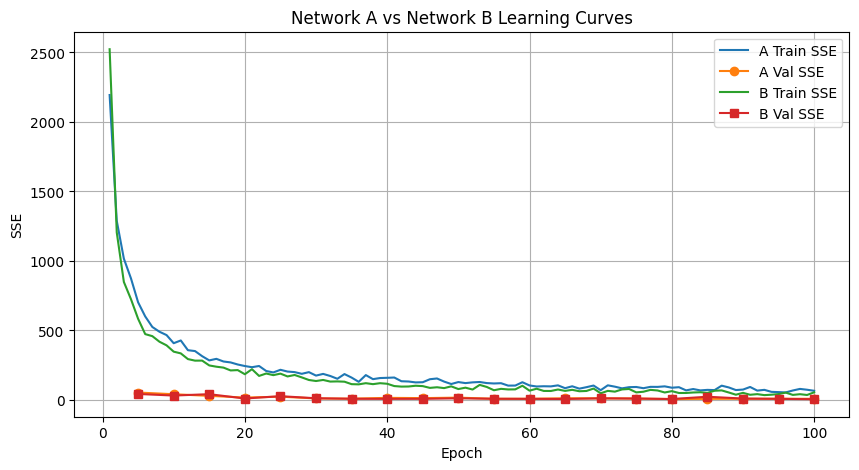

In [28]:
# Combined learning curves figure for report

plt.figure(figsize=(10, 5))
plt.plot(best_results_a["train_sse_history"][:, 0], best_results_a["train_sse_history"][:, 1], label="A Train SSE")
plt.plot(best_results_a["val_eval_history"][:, 0], best_results_a["val_eval_history"][:, 1], marker="o", label="A Val SSE")
plt.plot(best_results_b["train_sse_history"][:, 0], best_results_b["train_sse_history"][:, 1], label="B Train SSE")
plt.plot(best_results_b["val_eval_history"][:, 0], best_results_b["val_eval_history"][:, 1], marker="s", label="B Val SSE")
plt.xlabel("Epoch")
plt.ylabel("SSE")
plt.title("Network A vs Network B Learning Curves")
plt.legend()
plt.grid(True)
plt.show()